# 02 · Data Processing

In this notebook I clean every dataset using the decisions from `01_data_understanding.ipynb` and save each cleaned source to `processed/<source>_clean.parquet` in our Drive folder.

The weekly modelling table is built from these files in `03_model_table.ipynb`.

### Global conventions
| Topic | Rule |
|---|---|
| Time | Local calendar date (America/New_York). UTC sources are converted with `tz_convert` first. |
| Units | °C, mm, m/s, mg/L, µg/L, mg/m³, cells/L. °F → °C and inches → mm. |
| Coordinates | Longitude in −180 to 180 everywhere. |
| Study area | Sarasota box: lat 26.5–28, lon −83.5 to −81.8. |
| Grain | Cleaned sources are saved per sample / per day. They are aggregated to **weekly** in notebook 03. |
| Raw data | We never edit the raw files. All fixes are in code. |

## Setup

In [1]:
# Libraries used in this notebook
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation

In [2]:
# Mount Google Drive so we can read the data files
from google.colab import drive
drive.mount('/content/drive')

# Folder in Drive that holds all the raw data files
DATA = '/content/drive/MyDrive/biointerphase_data'

# Folder where the cleaned files are saved
PROCESSED = os.path.join(DATA, 'processed')
os.makedirs(PROCESSED, exist_ok=True)

print(os.listdir(DATA))

Mounted at /content/drive
['.gitkeep', 'MoteMarine_BottomTemp.csv', 'bradentonFL_tempData.csv', 'florida_cyanotoxins_2015-01-01_to_2026-06-17.csv', 'habsos_cellcounts.csv', 'Chlorophyll_subset_sarasota_2018_2026.nc', 'Sarasota_Wind&Temp.csv', 'SarasotaWindData.csv', 'NutrientsFL_2006_2025.csv', 'docs', 'processed']


In [3]:
# Sarasota study box
LAT_MIN, LAT_MAX = 26.5, 28.0
LON_MIN, LON_MAX = -83.5, -81.8

# Local time zone of Sarasota
LOCAL_TZ = 'America/New_York'


def in_box(lat, lon):
    """True for points inside the Sarasota study box."""
    return lat.between(LAT_MIN, LAT_MAX) & lon.between(LON_MIN, LON_MAX)


def utc_to_local_date(times):
    """Convert UTC time stamps to the local calendar date in Sarasota."""
    return times.dt.tz_convert(LOCAL_TZ).dt.tz_localize(None).dt.normalize()


def f_to_c(temp_f):
    """Convert degrees Fahrenheit to degrees Celsius."""
    return (temp_f - 32) * 5 / 9

---
## 1. HABSOS (target)

Steps:
1. Keep Florida samples inside the Sarasota box.
2. Keep surface samples (depth ≤ 2 m, or depth missing).
3. Drop exact duplicates. For conflicting duplicates keep the max `CELLCOUNT`.
4. Recompute `CATEGORY` and the 3-class label from `CELLCOUNT`.
5. Water temp > 40 °C and salinity > 45 ppt → NaN. Drop the empty wind columns.

**Label classes** (to be confirmed with the advisor):

| Class | Cells/L |
|---|---|
| 0 No bloom | < 10,000 |
| 1 At risk | 10,000 – 99,999 |
| 2 Bloom | ≥ 100,000 |

In [4]:
habsos = pd.read_csv(os.path.join(DATA, 'habsos_cellcounts.csv'), low_memory=False)
habsos['SAMPLE_DATE'] = pd.to_datetime(habsos['SAMPLE_DATE'])
print('Raw rows:', len(habsos))

# 1. Florida samples inside the study box
habsos = habsos[(habsos['STATE_ID'] == 'FL') & in_box(habsos['LATITUDE'], habsos['LONGITUDE'])]
print('Florida, inside the box:', len(habsos))

# 2. Surface samples only
habsos = habsos[(habsos['SAMPLE_DEPTH'] <= 2) | habsos['SAMPLE_DEPTH'].isna()]
print('Surface samples:', len(habsos))

Raw rows: 219152
Florida, inside the box: 120489
Surface samples: 105292


In [5]:
# 3. Exact duplicates (OBJECTID is just a row number, so drop it first)
habsos = habsos.drop(columns='OBJECTID').drop_duplicates()
print('After dropping exact duplicates:', len(habsos))

# Conflicting duplicates: same place, time and depth. Keep the highest cell count.
key = ['LATITUDE', 'LONGITUDE', 'SAMPLE_DATE', 'SAMPLE_DEPTH']
habsos = habsos.sort_values('CELLCOUNT', ascending=False).drop_duplicates(subset=key, keep='first')
habsos = habsos.sort_values('SAMPLE_DATE').reset_index(drop=True)
print('After dropping conflicting duplicates:', len(habsos))

After dropping exact duplicates: 104058
After dropping conflicting duplicates: 103351


In [6]:
# 4. Recompute the FWC category and our 3-class label from CELLCOUNT
habsos['CATEGORY'] = pd.cut(habsos['CELLCOUNT'],
                            bins=[-np.inf, 1, 10000, 100000, 1000000, np.inf],
                            labels=['not observed', 'very low', 'low', 'medium', 'high'],
                            right=False)

habsos['hab_class'] = pd.cut(habsos['CELLCOUNT'],
                             bins=[-np.inf, 10000, 100000, np.inf],
                             labels=[0, 1, 2],
                             right=False).astype(float)

print(habsos['CATEGORY'].value_counts(dropna=False), '\n')
print(habsos['hab_class'].value_counts(dropna=False))

CATEGORY
not observed    78325
very low        10068
low              6446
medium           6342
high             2170
Name: count, dtype: int64 

hab_class
0.0    88393
2.0     8512
1.0     6446
Name: count, dtype: int64


In [7]:
# 5. Impossible values -> NaN, drop the empty wind columns
habsos.loc[habsos['WATER_TEMP'] > 40, 'WATER_TEMP'] = np.nan
habsos.loc[habsos['SALINITY'] > 45, 'SALINITY'] = np.nan

wind_cols = [col for col in habsos.columns if col.startswith('WIND_')]
habsos = habsos.drop(columns=wind_cols)

# Date only (22% of the times are 00:00 = unknown time of day)
habsos['date'] = habsos['SAMPLE_DATE'].dt.normalize()

print('Columns:', habsos.columns.tolist())

Columns: ['DESCRIPTION', 'LATITUDE', 'LONGITUDE', 'STATE_ID', 'SAMPLE_DATE', 'SAMPLE_DEPTH', 'GENUS', 'SPECIES', 'CATEGORY', 'CELLCOUNT', 'CELLCOUNT_UNIT', 'CELLCOUNT_QA', 'SALINITY', 'SALINITY_UNIT', 'SALINITY_QA', 'WATER_TEMP', 'WATER_TEMP_UNIT', 'WATER_TEMP_QA', 'QA_COMMENT', 'hab_class', 'date']


In [8]:
# Check: samples per year (2022-2023 should stand out as nearly empty)
habsos['date'].dt.year.value_counts().sort_index().loc[2015:]

,count
date,
2015,2978
2016,4184
2017,4498
2018,5044
2019,4573
2020,3833
2021,2901
2022,177
2023,179


In [9]:
habsos.to_parquet(os.path.join(PROCESSED, 'habsos_clean.parquet'), index=False)
print('Saved habsos_clean.parquet:', habsos.shape)

Saved habsos_clean.parquet: (103351, 21)


---
## 2. Nutrients

Steps:
1. Drop exact duplicate rows and harmonise the `Characteristic` names (keep only the parameters we need).
2. Below detection (`U` qualifier): keep a flag and use MDL / 2 as the value.
3. Water temperature > 100 °F → NaN, then convert to °C. pH outside 0–14 → NaN. DO > 25 mg/L → NaN.
4. Collapse duplicate rows of the same sample to one value per station × date × parameter × depth class. Flag pairs that differ by ~1000× (unit errors) and keep the smaller value.
5. Pivot long → wide: one row per station × date (surface samples, to match HABSOS).

There are no station coordinates, so nutrients are joined at region level in notebook 03.

In [10]:
nutr = pd.read_csv(os.path.join(DATA, 'NutrientsFL_2006_2025.csv'), low_memory=False)
print('Raw rows:', len(nutr))

# 1. Exact duplicates
nutr = nutr.drop_duplicates()
print('After dropping exact duplicates:', len(nutr))

nutr['date'] = pd.to_datetime(nutr['Activity_Start_Date'], format='%m/%d/%Y %H:%M').dt.normalize()

Raw rows: 514087
After dropping exact duplicates: 506713


In [11]:
# 1. One short name per parameter (the name variants map to the same short name)
NUTRIENT_NAMES = {
    'Chlorophyll a, corrected for pheophytin': 'chla_corr_ugL',
    'Nitrogen': 'tn_mgL',
    'Nitrogen, Kjeldahl': 'tkn_mgL',
    'Nitrogen, Nitrite (NO2) + Nitrate (NO3) as N': 'nox_mgL',
    'Nitrogen, ammonia as N': 'nh3_mgL',
    'Phosphorus as P': 'tp_mgL',
    'Phosphorus, phosphate (PO4) as P': 'po4_mgL',
    'Dissolved oxygen (DO)': 'do_mgL',
    'Dissolved oxygen saturation': 'do_sat_pct',
    'Dissolved Oxygen Saturation': 'do_sat_pct',
    'Temperature, water': 'water_temp_c',
    'Temperature, Water': 'water_temp_c',
    'Turbidity': 'turbidity_ntu',
    'Total Suspended Solids (TSS)': 'tss_mgL',
    'Specific conductance': 'cond_umho',
    'Specific Conductance': 'cond_umho',
    'pH': 'ph',
}

nutr['param'] = nutr['Characteristic'].map(NUTRIENT_NAMES)
nutr = nutr[nutr['param'].notna()].copy()
nutr['value'] = nutr['Result_Value']

print('Rows kept:', len(nutr))
nutr['param'].value_counts()

Rows kept: 460120


,count
param,
do_sat_pct,57419
cond_umho,56764
water_temp_c,55210
ph,54392
do_mgL,27140
po4_mgL,26519
tkn_mgL,26372
tp_mgL,26340
chla_corr_ugL,26203


In [12]:
# 2. Below detection limit: flag it and use MDL / 2
#    (when MDL is blank, the reported value is the detection limit)
nutr['below_detect'] = nutr['Value_Qualifier'].fillna('').str.contains('U')
mdl = nutr['MDL'].fillna(nutr['Result_Value'])
nutr.loc[nutr['below_detect'], 'value'] = mdl[nutr['below_detect']] / 2

print('Below-detection rows:', nutr['below_detect'].sum())

Below-detection rows: 17302


In [13]:
# 3. Water temperature: values above 100 F are impossible, then convert F -> C
is_temp = nutr['param'] == 'water_temp_c'
nutr.loc[is_temp & (nutr['value'] > 100), 'value'] = np.nan
nutr.loc[is_temp, 'value'] = f_to_c(nutr.loc[is_temp, 'value'])

# pH must be between 0 and 14
is_ph = nutr['param'] == 'ph'
nutr.loc[is_ph & ((nutr['value'] < 0) | (nutr['value'] > 14)), 'value'] = np.nan

# Dissolved oxygen above 25 mg/L is not realistic
nutr.loc[(nutr['param'] == 'do_mgL') & (nutr['value'] > 25), 'value'] = np.nan

print('Water temp (C) min / max:', nutr.loc[is_temp, 'value'].min(), nutr.loc[is_temp, 'value'].max())

Water temp (C) min / max: 0.3200000000000003 37.199999999999996


In [14]:
# 4. One value per station x date x parameter x depth class
nutr['depth_class'] = nutr['RelativeDepth'].fillna('Unknown')
key = ['Actual_StationID', 'date', 'param', 'depth_class']

nutr_long = nutr.groupby(key).agg(
    value_min=('value', 'min'),
    value_max=('value', 'max'),
    value_median=('value', 'median'),
    n_rows=('value', 'size'),
    below_detect=('below_detect', 'max'),
).reset_index()

# Unit errors: two values of the same sample that are more than 500x apart
nutr_long['unit_error'] = (nutr_long['value_min'] > 0) & (nutr_long['value_max'] > 500 * nutr_long['value_min'])

# Keep the smaller value for unit errors, otherwise the median
nutr_long['value'] = np.where(nutr_long['unit_error'], nutr_long['value_min'], nutr_long['value_median'])

print('Rows after collapsing:', len(nutr_long))
print('Unit errors by parameter:')
print(nutr_long.loc[nutr_long['unit_error'], 'param'].value_counts())

Rows after collapsing: 435168
Unit errors by parameter:
param
nh3_mgL    574
Name: count, dtype: int64


In [15]:
# 5. Pivot to wide: one row per station x date, surface samples only
#    (the coastal creek stations have no depth class, so 'Unknown' is kept too)
surface = nutr_long[nutr_long['depth_class'].isin(['Surface', 'Unknown'])]

nutr_wide = surface.pivot_table(index=['Actual_StationID', 'date'], columns='param', values='value', aggfunc='mean')
nutr_wide = nutr_wide.reset_index().rename(columns={'Actual_StationID': 'station_id'})
nutr_wide.columns.name = None

print('Shape:', nutr_wide.shape)
nutr_wide.describe().T[['count', 'mean', 'min', 'max']]

Shape: (26904, 16)


,count,mean,min,max
date,26904,2014-10-13 06:37:15.147190016,1998-02-24 00:00:00,2025-12-29 00:00:00
chla_corr_ugL,11191.0,18.360811,0.125,4333.0
cond_umho,24042.0,28390.868254,0.0,66296.2
do_mgL,23800.0,5.917212,0.0,24.7
do_sat_pct,25011.0,79.074605,0.0,284.0
nh3_mgL,10968.0,0.141143,0.000004,16.8
nox_mgL,10684.0,0.126593,0.001,4.59
ph,23988.0,7.669733,2.2,10.75
po4_mgL,11757.0,0.235388,0.001,3.72
tkn_mgL,11435.0,1.248867,0.025,54.6


In [16]:
# Save the long table (keeps the below_detect / unit_error flags) and the wide table
nutr_long = nutr_long.rename(columns={'Actual_StationID': 'station_id'})
nutr_long.to_parquet(os.path.join(PROCESSED, 'nutrients_long_clean.parquet'), index=False)
nutr_wide.to_parquet(os.path.join(PROCESSED, 'nutrients_clean.parquet'), index=False)
print('Saved nutrients_long_clean.parquet:', nutr_long.shape)
print('Saved nutrients_clean.parquet:', nutr_wide.shape)

Saved nutrients_long_clean.parquet: (435168, 11)
Saved nutrients_clean.parquet: (26904, 16)


---
## 3. Bradenton weather

Sentinels → NaN, recompute mean temperature as (max + min) / 2, °F → °C and inches → mm.

In [17]:
# -99.9 and -99.99 are "missing" codes, header names have leading spaces
brad = pd.read_csv(os.path.join(DATA, 'bradentonFL_tempData.csv'),
                   skipinitialspace=True, na_values=[-99.9, -99.99])
brad.columns = brad.columns.str.strip()
brad['date'] = pd.to_datetime(dict(year=brad['YEAR'], month=brad['MONTH'], day=brad['DAY']))

brad_clean = pd.DataFrame({
    'date': brad['date'],
    'rain_mm': brad['PRECIPITATION'] * 25.4,
    'air_tmax_c': f_to_c(brad['MAX TEMP']),
    'air_tmin_c': f_to_c(brad['MIN TEMP']),
})

# The MEAN TEMP column is 18% blank, so recompute it for every day
brad_clean['air_tmean_c'] = (brad_clean['air_tmax_c'] + brad_clean['air_tmin_c']) / 2

print('Missing values after cleaning:')
print(brad_clean.isna().sum())
brad_clean.describe().T[['min', 'max']]

Missing values after cleaning:
date           0
rain_mm        5
air_tmax_c     7
air_tmin_c     8
air_tmean_c    9
dtype: int64


,min,max
date,2015-01-01 00:00:00,2025-12-31 00:00:00
rain_mm,0.0,295.91
air_tmax_c,7.222222,38.333333
air_tmin_c,-1.666667,28.333333
air_tmean_c,4.166667,32.777778


In [18]:
brad_clean.to_parquet(os.path.join(PROCESSED, 'bradenton_clean.parquet'), index=False)
print('Saved bradenton_clean.parquet:', brad_clean.shape)

Saved bradenton_clean.parquet: (4018, 5)


---
## 4. Wind

### 4a. KSRQ airport station
Air temperature outside −10 to 45 °C → NaN. Wind speed and direction → u / v components (we never average degrees). Then daily means on the local date.

In [19]:
# Row 2 is a units row
ksrq = pd.read_csv(os.path.join(DATA, 'Sarasota_Wind&Temp.csv'), skiprows=[1])
ksrq['time'] = pd.to_datetime(ksrq['time'], utc=True)

# Impossible air temperatures -> NaN
bad_temp = (ksrq['air_temperature'] < -10) | (ksrq['air_temperature'] > 45)
ksrq.loc[bad_temp, 'air_temperature'] = np.nan
print('Air temperatures set to NaN:', bad_temp.sum())

# Wind "from" direction -> u (east-west) and v (north-south) components
radians = np.deg2rad(ksrq['wind_from_direction'])
ksrq['wind_u'] = -ksrq['wind_speed'] * np.sin(radians)
ksrq['wind_v'] = -ksrq['wind_speed'] * np.cos(radians)

Air temperatures set to NaN: 7


In [20]:
# Daily means on the local date (this also takes care of the sub-hourly special reports)
ksrq['date'] = utc_to_local_date(ksrq['time'])

ksrq_daily = ksrq.groupby('date').agg(
    ksrq_pressure_hpa=('air_pressure_at_mean_sea_level', 'mean'),
    ksrq_air_temp_c=('air_temperature', 'mean'),
    ksrq_dew_point_c=('dew_point_temperature', 'mean'),
    ksrq_wind_speed=('wind_speed', 'mean'),
    ksrq_wind_u=('wind_u', 'mean'),
    ksrq_wind_v=('wind_v', 'mean'),
).reset_index()

print('Days:', len(ksrq_daily))
ksrq_daily.describe().T[['min', 'max']]

Days: 1439


,min,max
date,2022-07-11 00:00:00,2026-06-18 00:00:00
ksrq_pressure_hpa,995.056522,1028.829167
ksrq_air_temp_c,5.25,31.874074
ksrq_dew_point_c,-5.016667,26.230769
ksrq_wind_speed,0.622749,14.204383
ksrq_wind_u,-7.84976,8.227215
ksrq_wind_v,-11.71758,10.400141


In [21]:
ksrq_daily.to_parquet(os.path.join(PROCESSED, 'ksrq_clean.parquet'), index=False)
print('Saved ksrq_clean.parquet:', ksrq_daily.shape)

Saved ksrq_clean.parquet: (1439, 7)


### 4b. Gridded ocean wind (`uwnd` only)
Longitude 0–360 → −180 to 180. Keep the **offshore** cells (the three western grid columns, longitude ≤ −82.875, are over the Gulf at every latitude), then daily mean on the local date.

**`vwnd` is missing**, so speed, direction and the alongshore / cross-shore components can't be computed yet. Once `vwnd` is added: speed = √(u² + v²), and the alongshore component is the wind projected on the coastline direction (roughly NNW–SSE at Sarasota).

In [22]:
# Row 2 is a units row
uwnd = pd.read_csv(os.path.join(DATA, 'SarasotaWindData.csv'), skiprows=[1])
uwnd['time'] = pd.to_datetime(uwnd['time'], utc=True)
uwnd['longitude'] = uwnd['longitude'] - 360

# Offshore cells only
offshore = uwnd[uwnd['longitude'] <= -82.875].copy()
print('Offshore cells:', offshore[['latitude', 'longitude']].drop_duplicates().shape[0])

# Daily mean over the offshore cells
offshore['date'] = utc_to_local_date(offshore['time'])
uwnd_daily = offshore.groupby('date')['uwnd'].mean().reset_index()
uwnd_daily = uwnd_daily.rename(columns={'uwnd': 'uwnd_offshore'})

print('Days:', len(uwnd_daily))
uwnd_daily.describe().T[['min', 'max']]

Offshore cells: 21
Days: 2815


,min,max
date,2018-12-31 00:00:00,2026-09-15 00:00:00
uwnd_offshore,-12.286818,12.256139


In [23]:
uwnd_daily.to_parquet(os.path.join(PROCESSED, 'wind_grid_clean.parquet'), index=False)
print('Saved wind_grid_clean.parquet:', uwnd_daily.shape)

Saved wind_grid_clean.parquet: (2815, 2)


---
## 5. Mote water temperature

Drop QC 3 / 4 rows, then daily mean and max on the local date. The Mar 2023 → Mar 2024 gap stays as missing days.

In [24]:
# Row 2 is a units row
mote = pd.read_csv(os.path.join(DATA, 'MoteMarine_BottomTemp.csv'), skiprows=[1])
mote['time'] = pd.to_datetime(mote['time'], utc=True)

# Drop suspect (3) and failed (4) readings
mote = mote[~mote['sea_water_temperature_qc_agg'].isin([3, 4])].copy()

mote['date'] = utc_to_local_date(mote['time'])
mote_daily = mote.groupby('date').agg(
    mote_temp_mean_c=('sea_water_temperature', 'mean'),
    mote_temp_max_c=('sea_water_temperature', 'max'),
).reset_index()

print('Days:', len(mote_daily))
mote_daily.describe().T[['min', 'max']]

Days: 1324


,min,max
date,2020-08-13 00:00:00,2025-03-26 00:00:00
mote_temp_mean_c,11.882375,32.50975
mote_temp_max_c,12.412,33.046


In [25]:
mote_daily.to_parquet(os.path.join(PROCESSED, 'mote_clean.parquet'), index=False)
print('Saved mote_clean.parquet:', mote_daily.shape)

Saved mote_clean.parquet: (1324, 3)


---
## 6. Satellite chlorophyll (7A)

- Clip values at 50 mg/m³ (turbid nearshore water) before averaging.
- **Ocean pixels** = pixels with data on at least half of the days. (About 1,000 pixels over land and inland lakes have data on less than 1% of days, so "has data at least once" is not a good ocean mask.)
- **Coastal pixels** = ocean pixels within ~20 km of land (10 pixels of ~2 km).
- Daily median of the coastal pixels and of the whole box.

The time stamps are 12:00 UTC (08:00 local), so the date part is already the local date.

In [26]:
ds = xr.open_dataset(os.path.join(DATA, 'Chlorophyll_subset_sarasota_2018_2026.nc'))
chl = ds['chlor_a'].load()

# Use the date only
chl = chl.assign_coords(time=pd.to_datetime(chl['time'].values).normalize())

# Clip very high nearshore values
chl = chl.clip(max=50)

# Ocean = pixels with data on at least half of the days, everything else is land
ocean = chl.notnull().mean('time') >= 0.5

# Coastal = ocean pixels within 10 pixels (~20 km) of land
near_land = binary_dilation(~ocean.values, iterations=10)
coastal = ocean & near_land

print('Ocean pixels:', int(ocean.sum()), '| Coastal pixels:', int(coastal.sum()))

Ocean pixels: 4001 | Coastal pixels: 1161


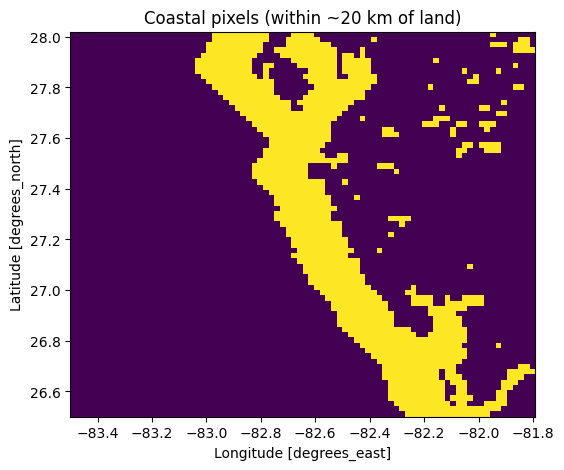

In [27]:
# Check the coastal mask on a map
coastal.astype(int).plot(figsize=(6, 5), add_colorbar=False)
plt.title('Coastal pixels (within ~20 km of land)')
plt.show()

In [28]:
# Daily medians (days with no valid pixels stay NaN)
chl_daily = pd.DataFrame({
    'date': pd.to_datetime(chl['time'].values),
    'chl_box_median': chl.where(ocean).median(['latitude', 'longitude']).values,
    'chl_coastal_median': chl.where(coastal).median(['latitude', 'longitude']).values,
})

print('Days:', len(chl_daily))
chl_daily.describe().T[['count', 'min', 'max']]

Days: 3160


,count,min,max
date,3160,2018-01-01 00:00:00,2026-09-10 00:00:00
chl_box_median,3155.0,0.174216,7.017734
chl_coastal_median,3153.0,1.505668,21.934454


In [29]:
chl_daily.to_parquet(os.path.join(PROCESSED, 'chlorophyll_clean.parquet'), index=False)
print('Saved chlorophyll_clean.parquet:', chl_daily.shape)

Saved chlorophyll_clean.parquet: (3160, 3)


---
## 7. Cyanotoxins (optional)

Normalise the dates, keep sites inside the Sarasota box, and add `detected` = value above the detection limit.

In [30]:
cyano = pd.read_csv(os.path.join(DATA, 'florida_cyanotoxins_2015-01-01_to_2026-06-17.csv'), low_memory=False)

# Dates are epoch milliseconds; the day part is correct
cyano['date'] = pd.to_datetime(cyano['Activity_StartDate'], unit='ms').dt.normalize()

# Sites inside the study box
cyano = cyano[in_box(cyano['Location_Latitude'], cyano['Location_Longitude'])]

cyano_clean = pd.DataFrame({
    'date': cyano['date'],
    'site_id': cyano['Location_Identifier'],
    'site_type': cyano['Location_Type'],
    'latitude': cyano['Location_Latitude'],
    'longitude': cyano['Location_Longitude'],
    'toxin': cyano['Result_Characteristic'],
    'value_ugL': cyano['Reslt_Measre'],
    'detection_limit_ugL': cyano['DetectionLimit_MeasureA'],
})
cyano_clean['detected'] = cyano_clean['value_ugL'] > cyano_clean['detection_limit_ugL']

print('Rows in the box:', len(cyano_clean))
print('Detections in the box:', cyano_clean['detected'].sum())

Rows in the box: 7058
Detections in the box: 175


In [31]:
cyano_clean.to_parquet(os.path.join(PROCESSED, 'cyanotoxins_clean.parquet'), index=False)
print('Saved cyanotoxins_clean.parquet:', cyano_clean.shape)

Saved cyanotoxins_clean.parquet: (7058, 9)


---
## Saved files

In [32]:
for name in sorted(os.listdir(PROCESSED)):
    size_mb = os.path.getsize(os.path.join(PROCESSED, name)) / 1e6
    print(f'{name:35s} {size_mb:6.2f} MB')

bradenton_clean.parquet               0.05 MB
chlorophyll_clean.parquet             0.07 MB
cyanotoxins_clean.parquet             0.05 MB
habsos_clean.parquet                  2.06 MB
ksrq_clean.parquet                    0.09 MB
mote_clean.parquet                    0.03 MB
nutrients_clean.parquet               0.57 MB
nutrients_long_clean.parquet          3.88 MB
wind_grid_clean.parquet               0.05 MB


**Next:** `03_model_table.ipynb` aggregates these files to weekly and joins them into the modelling table.